In [1]:
# Validação de setup — circuito Bell em simulador local
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Construir circuito Bell (entrelaçamento de 2 qubits)
qc = QuantumCircuit(2, 2)
qc.h(0)              # Hadamard no qubit 0 — cria superposição
qc.cx(0, 1)          # CNOT — entrelaça qubit 0 com qubit 1
qc.measure([0, 1], [0, 1])

print("Circuito construído:")
print(qc.draw())

Circuito construído:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [2]:
# Executar no simulador local
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print(f"Resultados ({sum(counts.values())} shots):")
for outcome, count in sorted(counts.items()):
    pct = 100 * count / sum(counts.values())
    print(f"  |{outcome}⟩: {count:4d} ({pct:.1f}%)")

Resultados (1024 shots):
  |00⟩:  490 (47.9%)
  |11⟩:  534 (52.1%)


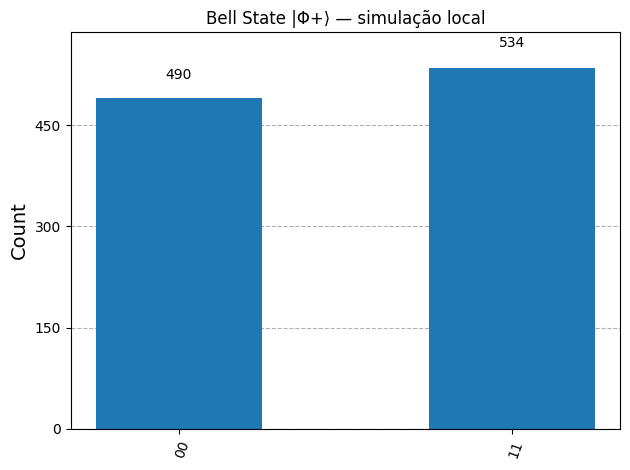

In [3]:
# Visualizar
plot_histogram(counts, title="Bell State |Φ+⟩ — simulação local")

In [5]:
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService

load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")
instance = os.getenv("IBM_QUANTUM_INSTANCE")

# Salvar credenciais localmente (faz isso uma vez só)
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    instance=instance,
    overwrite=True,
)

# Validar conexão
service = QiskitRuntimeService()
print("Conexão estabelecida com IBM Quantum.")
print(f"\nQPUs disponíveis:")
for backend in service.backends():
    print(f"  - {backend.name}: {backend.num_qubits} qubits, status: {backend.status().status_msg}")

/Users/hugomastromaurodasilva/Projects/quantum-agro-br/.venv/lib/python3.10/site-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Conexão estabelecida com IBM Quantum.

QPUs disponíveis:
  - ibm_fez: 156 qubits, status: active
  - ibm_kingston: 156 qubits, status: active
  - ibm_marrakesh: 156 qubits, status: active
